In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/ML final project'

if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)
    print(f"it created: {PROJECT_PATH}")

%cd {PROJECT_PATH}

Mounted at /content/drive
/content/drive/MyDrive/ML final project


In [2]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import mlflow
import mlflow.sklearn

In [4]:
import os
# ვბეჭდავთ მიმდინარე ფოლდერში არსებული ყველა ფაილის სიას
print(os.listdir('.'))

['walmart-recruiting-store-sales-forecasting.zip', 'walmart_data', '.ipynb_checkpoints', '__pycache__', 'feature_importance.png', 'data_preprocessing.ipynb', 'learning_curve.png', 'LightGBM', 'xgboost_walmart_submission_mlflow.csv', 'custom_transformers.py', 'walmart_transformers.py', 'N-BEATS.ipynb', 'XGBoost.ipynb', 'submission.csv', 'submission_v2.csv', 'model_inference_XGBoost.ipynb']


In [1]:
!pip install darts pytorch-lightning matplotlib pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.8/808.8 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.9 MB/s eta 0:00:00


In [4]:
from walmart_transformers import WalmartDataTransformer, TimeSeriesSplitter

In [ ]:
!pip install dagshub

In [ ]:
import dagshub
dagshub.init(repo_owner='mesata', repo_name='Walmart---Store-Sales-Forecasting', mlflow=True)

In [9]:
train_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/train.csv.zip')
features_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/features.csv.zip')
stores_df = pd.read_csv('/content/drive/MyDrive/ML final project/walmart_data/stores.csv')

In [ ]:
import importlib
import walmart_transformers

importlib.reload(walmart_transformers)

from walmart_transformers import WalmartDataTransformer, TimeSeriesSplitter

In [10]:
splitter = TimeSeriesSplitter(split_date='2012-01-01')
X_train, y_train, X_val, y_val = splitter.split(train_df)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

Train: (294132, 4), Validation: (127438, 4)


In [ ]:
import mlflow
import mlflow.sklearn
import numpy as np
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mlflow.set_experiment("XGBoost")

with mlflow.start_run(run_name="XGBoost_Baseline"):

    n_estimators = 100
    max_depth = 6
    learning_rate = 0.1

    baseline_pipeline = Pipeline([
        ('data_prep', WalmartDataTransformer(features_df, stores_df)),
        ('model', xgb.XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            random_state=42
        ))
    ])


    baseline_pipeline.fit(X_train, y_train)

    train_preds = baseline_pipeline.predict(X_train)
    val_preds = baseline_pipeline.predict(X_val)

    X_train_trans = baseline_pipeline.named_steps['data_prep'].transform(X_train)
    X_val_trans = baseline_pipeline.named_steps['data_prep'].transform(X_val)

    train_weights = X_train_trans['IsHoliday'].map(lambda x: 5 if x == 1 else 1)
    val_weights = X_val_trans['IsHoliday'].map(lambda x: 5 if x == 1 else 1)

    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)

    train_wmae = mean_absolute_error(y_train, train_preds, sample_weight=train_weights)
    val_wmae = mean_absolute_error(y_val, val_preds, sample_weight=val_weights)

    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    val_r2 = r2_score(y_val, val_preds)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    train_r2 = r2_score(y_train, train_preds)

    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("split_date", "2012-01-01")
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("learning_rate", learning_rate)

    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("train_wmae", train_wmae)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("train_r2", train_r2)

    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_wmae", val_wmae)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.sklearn.log_model(baseline_pipeline, "model", serialization_format="cloudpickle")

    print("-" * 30)
    print(f"run ended")
    print(f"Train MAE: ${train_mae:,.2f} | Train WMAE: ${train_wmae:,.2f}")
    print(f"Validation MAE: ${val_mae:,.2f} | Validation WMAE: ${val_wmae:,.2f}")

2026/07/08 13:19:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 13:19:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


------------------------------
run ended
Train MAE: $3,898.24 | Train WMAE: $4,052.26
Validation MAE: $3,935.79 | Validation WMAE: $3,977.81
🏃 View run XGBoost_Baseline at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/eecbd6dbf6cc43e6b497f0b6cb963528
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

mlflow.set_experiment("XGBoost")

# Search Space of parameters
param_distributions = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 7, 9],
    'model__learning_rate': [0.03, 0.07, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

tune_pipeline = Pipeline([
    ('data_prep', WalmartDataTransformer(features_df, stores_df)),
    ('model', xgb.XGBRegressor(random_state=42, n_jobs=-1))
])

print("hyperparameters search started")

# RandomizedSearchCV
# n_iter=5 test 5 different combination
# cv=3 () 3-Fold validation on each combination
random_search = RandomizedSearchCV(
    estimator=tune_pipeline,
    param_distributions=param_distributions,
    n_iter=5,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print("hyperparameters search ended")

best_pipeline = random_search.best_estimator_

with mlflow.start_run(run_name="XGBoost_Hyperparametes_Tuned"):

    train_preds = best_pipeline.predict(X_train)
    val_preds = best_pipeline.predict(X_val)

    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)

    train_wmae = mean_absolute_error(y_train, train_preds, sample_weight=train_weights)
    val_wmae = mean_absolute_error(y_val, val_preds, sample_weight=val_weights)

    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    val_r2 = r2_score(y_val, val_preds)

    best_params = random_search.best_params_
    mlflow.log_param("model_type", "XGBoost_Tuned")
    mlflow.log_param("split_date", "2012-01-01")
    mlflow.log_param("n_estimators", best_params['model__n_estimators'])
    mlflow.log_param("max_depth", best_params['model__max_depth'])
    mlflow.log_param("learning_rate", best_params['model__learning_rate'])

    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.log_metric("train_wmae", train_wmae)
    mlflow.log_metric("val_wmae", val_wmae)


    mlflow.sklearn.log_model(best_pipeline, "hyperparamethers_tuned_model",serialization_format="cloudpickle")

    print("-" * 30)
    print(f"run ended")
    print(f"Train MAE: ${train_mae:,.2f} | Train WMAE: ${train_wmae:,.2f}")
    print(f"Validation MAE: ${val_mae:,.2f} | Validation WMAE: ${val_wmae:,.2f}")

hyperparameters search started
hyperparameters search ended


2026/07/08 13:30:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 13:30:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


------------------------------
run ended
Train MAE: $3,598.26 | Train WMAE: $3,748.09
Validation MAE: $3,711.25 | Validation WMAE: $3,744.20
🏃 View run XGBoost_Hyperparametes_Tuned at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/8b1d8fdefca045a3a179e92b97d808b5
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0


In [ ]:
param_distributions_adv = {
    'model__n_estimators': [200, 300, 400],
    'model__max_depth': [6, 7, 8, 10],
    'model__learning_rate': [0.02, 0.03, 0.05],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9],
    'model__min_child_weight': [1, 3, 5],
    'model__gamma': [0, 0.1, 0.2]
}

adv_pipeline = Pipeline([
    ('data_prep', WalmartDataTransformer(features_df, stores_df)),
    ('model', xgb.XGBRegressor(random_state=42, n_jobs=-1))
])

adv_search = RandomizedSearchCV(
    estimator=adv_pipeline,
    param_distributions=param_distributions_adv,
    n_iter=15,
    cv=3,
    scoring='neg_mean_absolute_error',ა
    random_state=24, # different random_state
    n_jobs=1
)

adv_search.fit(X_train, y_train)

best_adv_pipeline = adv_search.best_estimator_

with mlflow.start_run(run_name="XGBoost_Advanced_Tuned"):

    train_preds = best_adv_pipeline.predict(X_train)
    val_preds = best_adv_pipeline.predict(X_val)

    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    val_r2 = r2_score(y_val, val_preds)

    train_wmae = mean_absolute_error(y_train, train_preds, sample_weight=train_weights)
    val_wmae = mean_absolute_error(y_val, val_preds, sample_weight=val_weights)


    best_params = adv_search.best_params_
    mlflow.log_param("model_type", "XGBoost_Advanced")
    mlflow.log_param("split_date", "2012-01-01")
    mlflow.log_param("n_estimators", best_params['model__n_estimators'])
    mlflow.log_param("max_depth", best_params['model__max_depth'])
    mlflow.log_param("learning_rate", best_params['model__learning_rate'])
    mlflow.log_param("min_child_weight", best_params['model__min_child_weight'])

    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.log_metric("train_wmae", train_wmae)
    mlflow.log_metric("val_wmae", val_wmae)

    mlflow.sklearn.log_model(best_adv_pipeline, "advanced_model",serialization_format="cloudpickle")

    print("-" * 30)
    print(f"run ended")
    print(f"Train MAE: ${train_mae:,.2f} | Train WMAE: ${train_wmae:,.2f}")
    print(f"Validation MAE: ${val_mae:,.2f} | Validation WMAE: ${val_wmae:,.2f}")

2026/07/08 13:47:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 13:47:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


------------------------------
run ended
Train MAE: $2,327.12 | Train WMAE: $2,408.35
Validation MAE: $2,818.29 | Validation WMAE: $2,832.64
🏃 View run XGBoost_Advanced_Tuned at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/8510bba5ea9f484ebdc1bc697dbb662c
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0


CHANGED FEATURE ENGINEERING

In [ ]:
%%writefile -a walmart_transformers.py

class WalmartDataTransformer_updatedFeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self, features_df, stores_df):
        self.features_df = features_df
        self.stores_df = stores_df

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        df['Date'] = pd.to_datetime(df['Date'])
        self.features_df['Date'] = pd.to_datetime(self.features_df['Date'])

        df = df.merge(self.stores_df, on='Store', how='left')
        df = df.merge(self.features_df, on=['Store', 'Date'], how='left')

        df['CPI'] = df['CPI'].fillna(df['CPI'].median())
        df['Unemployment'] = df['Unemployment'].fillna(df['Unemployment'].median())

        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

        df['Is_December'] = (df['Month'] == 12).astype(int)
        df['Is_November'] = (df['Month'] == 11).astype(int)

        if 'Is_Holiday_x' in df.columns:
            df['Is_Holiday'] = df['Is_Holiday_x']
        elif 'Is_Holiday' not in df.columns and 'Is_Holiday_y' in df.columns:
            df['Is_Holiday'] = df['Is_Holiday_y']

        if 'Is_Holiday' in df.columns:
            df['Is_Holiday'] = df['Is_Holiday'].astype(int)
        else:
            df['Is_Holiday'] = 0

        if 'Type' in df.columns:
            df['Type'] = df['Type'].astype('category').cat.codes

        drop_cols = ['Date', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Is_Holiday_x', 'Is_Holiday_y']
        df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

        return df

Appending to walmart_transformers.py


In [ ]:
import importlib
import walmart_transformers
importlib.reload(walmart_transformers)
from walmart_transformers import WalmartDataTransformer_updatedFeatureEngineering, TimeSeriesSplitter
import xgboost as xgb
from sklearn.pipeline import Pipeline
import mlflow

# best params from last run
best_params = {
    'subsample': 0.9,
    'n_estimators': 400,
    'min_child_weight': 3,
    'max_depth': 8,
    'learning_rate': 0.05,
    'gamma': 0.2,
    'colsample_bytree': 0.8
}

# with new transformer
fe_pipeline = Pipeline([
    ('data_prep', WalmartDataTransformer_updatedFeatureEngineering(features_df, stores_df)),
    ('model', xgb.XGBRegressor(random_state=42, n_jobs=-1, **best_params))
])

fe_pipeline.fit(X_train, y_train)

with mlflow.start_run(run_name="XGBoost_New_Feature_Engineering"):
    train_preds = fe_pipeline.predict(X_train)
    val_preds = fe_pipeline.predict(X_val)

    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    val_r2 = r2_score(y_val, val_preds)
    train_wmae = mean_absolute_error(y_train, train_preds, sample_weight=train_weights)
    val_wmae = mean_absolute_error(y_val, val_preds, sample_weight=val_weights)


    mlflow.log_param("model_type", "XGBoost_Feature_Engineering")
    for param_name, param_val in best_params.items():
        mlflow.log_param(param_name, param_val)

    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_r2", val_r2)

    mlflow.log_metric("train_wmae", train_wmae)
    mlflow.log_metric("val_wmae", val_wmae)

    mlflow.sklearn.log_model(fe_pipeline, "advanced_model_plus_new_FE",serialization_format="cloudpickle")

    print("-" * 30)
    print(f"run ended")
    print(f"Train MAE: ${train_mae:,.2f} | Train WMAE: ${train_wmae:,.2f}")
    print(f"Validation MAE: ${val_mae:,.2f} | Validation WMAE: ${val_wmae:,.2f}")

2026/07/08 13:48:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 13:48:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


------------------------------
run ended
Train MAE: $2,207.73 | Train WMAE: $2,301.18
Validation MAE: $2,672.31 | Validation WMAE: $2,697.86
🏃 View run XGBoost_New_Feature_Engineering at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/626a4a01d4c040e6be6536f49b5de44d
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0


/tmp/ipykernel_3535/394896101.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='RdPu_r')


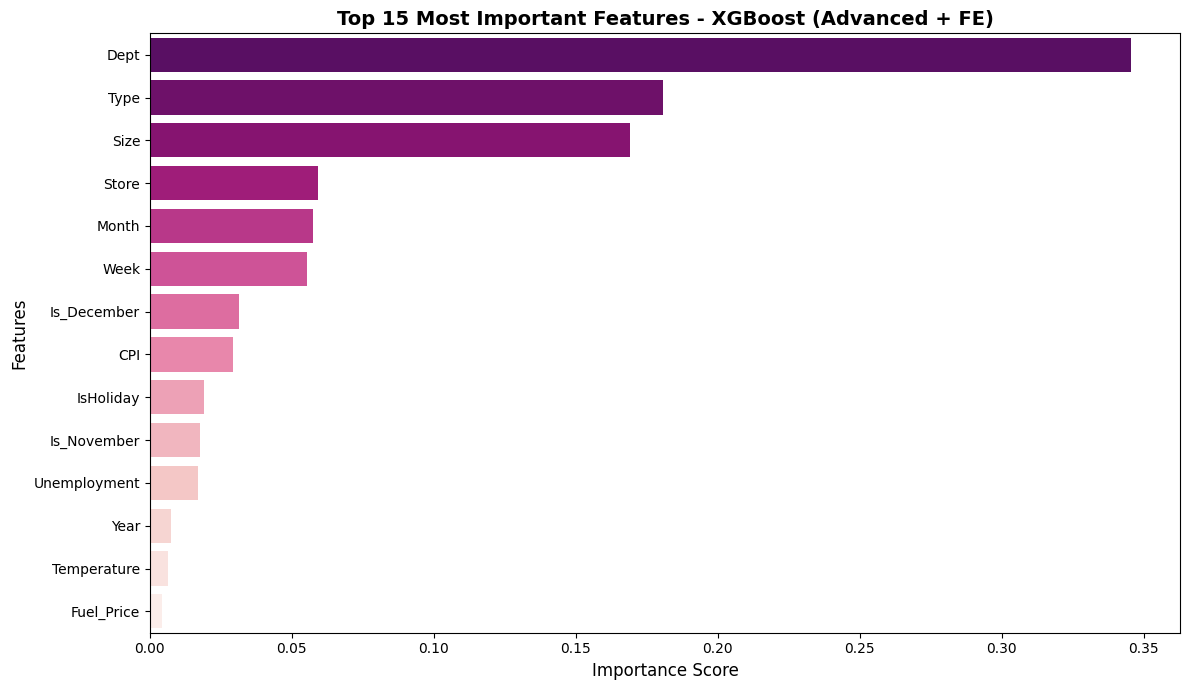

In [ ]:
import matplotlib.pyplot as plt
import seaborn
import seaborn as sns
import pandas as pd

xgb_model = fe_pipeline.named_steps['model']

transformed_X = fe_pipeline.named_steps['data_prep'].transform(X_train)
feature_names = transformed_X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='RdPu_r')
plt.title('Top 15 Most Important Features - XGBoost (Advanced + FE)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()

plt.savefig('feature_importance.png', dpi=300)
plt.show()

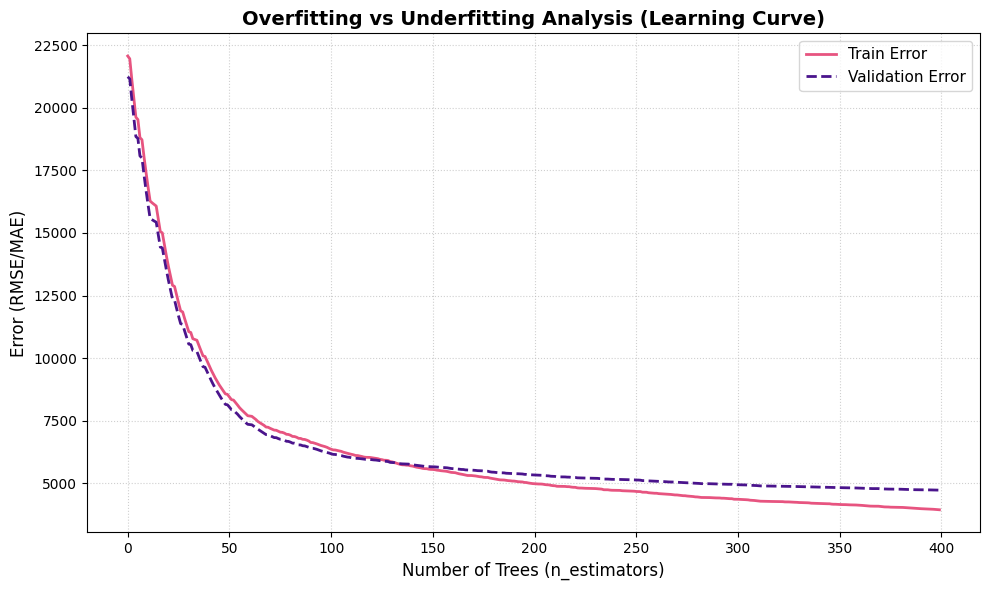

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
import numpy as np

transformer = fe_pipeline.named_steps['data_prep']
X_train_trans = transformer.transform(X_train)
X_val_trans = transformer.transform(X_val)


eval_model = xgb.XGBRegressor(
    subsample=0.9,
    n_estimators=400,
    min_child_weight=3,
    max_depth=8,
    learning_rate=0.05,
    gamma=0.2,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

eval_model.fit(
    X_train_trans, y_train,
    eval_set=[(X_train_trans, y_train), (X_val_trans, y_val)],
    verbose=False
)

results = eval_model.evals_result()
train_mae = results['validation_0']['rmse']
val_mae = results['validation_1']['rmse']
epochs = len(train_mae)


plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_mae, label='Train Error', color='#e75480', linewidth=2)
plt.plot(range(epochs), val_mae, label='Validation Error', color='#4a148c', linewidth=2, linestyle='--')

plt.title('Overfitting vs Underfitting Analysis (Learning Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('Error (RMSE/MAE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('learning_curve.png', dpi=300)
plt.show()

LAGS

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
import mlflow.sklearn
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from walmart_transformers import WalmartDataTransformer_updatedFeatureEngineering, TimeSeriesSplitter,WalmartLagTransformer


train_df_lags=train_df.copy()
train_df_lags['Lag_52'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52)
train_df_lags['Rolling_Mean_4_Yearly'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52).rolling(window=4).mean()

train_df_lags = train_df_lags.dropna(subset=['Lag_52', 'Rolling_Mean_4_Yearly'])

# 2. ამის შემდეგ აკეთებ Split-ს
splitter = TimeSeriesSplitter(split_date='2012-01-01', target_col='Weekly_Sales')
X_train_raw, y_train, X_val_raw, y_val = splitter.split(train_df_lags)

train_weights = X_train_raw['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values if 'IsHoliday' in X_train_raw.columns else None
val_weights = X_val_raw['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values if 'IsHoliday' in X_val_raw.columns else None


best_params = {
    'subsample': 0.9,
    'n_estimators': 400,
    'min_child_weight': 3,
    'max_depth': 8,
    'learning_rate': 0.05,
    'gamma': 0.2,
    'colsample_bytree': 0.8
}

adv_pipeline_with_lags = Pipeline([
    ('data_prep', WalmartDataTransformer_updatedFeatureEngineering(features_df, stores_df)),
    ('model', xgb.XGBRegressor(**best_params))
])


adv_pipeline_with_lags.fit(X_train_raw, y_train, model__sample_weight=train_weights)


with mlflow.start_run(run_name="XGBoost_with_Lags"):

    train_preds = adv_pipeline_with_lags.predict(X_train_raw)
    val_preds = adv_pipeline_with_lags.predict(X_val_raw)

    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    val_r2 = r2_score(y_val, val_preds)

    train_wmae = mean_absolute_error(y_train, train_preds, sample_weight=train_weights)
    val_wmae = mean_absolute_error(y_val, val_preds, sample_weight=val_weights)


    mlflow.log_param("model_type", "XGBoost_With_Lags_Pipeline")
    mlflow.log_param("split_date", "2012-01-01")
    mlflow.log_param("n_estimators", best_params['n_estimators'])
    mlflow.log_param("max_depth", best_params['max_depth'])
    mlflow.log_param("learning_rate", best_params['learning_rate'])


    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_r2", val_r2)
    mlflow.log_metric("train_wmae", train_wmae)
    mlflow.log_metric("val_wmae", val_wmae)

    mlflow.sklearn.log_model(adv_pipeline_with_lags, "all_in_one_lag_pipeline", serialization_format="cloudpickle")

    print("-" * 30)
    print(f"Lag Pipeline Run Ended Successfully!")
    print(f"Train MAE: ${train_mae:,.2f} | Train WMAE: ${train_wmae:,.2f}")
    print(f"Validation MAE: ${val_mae:,.2f} | Validation WMAE: ${val_wmae:,.2f}")

2026/07/11 03:28:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 03:28:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/11 03:29:06 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


------------------------------
Lag Pipeline Run Ended Successfully!
Train MAE: $1,124.54 | Train WMAE: $1,082.46
Validation MAE: $1,948.31 | Validation WMAE: $1,984.40
🏃 View run XGBoost_with_Lags at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/b569d9f16ae5436abd9ece66285d93ea
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0


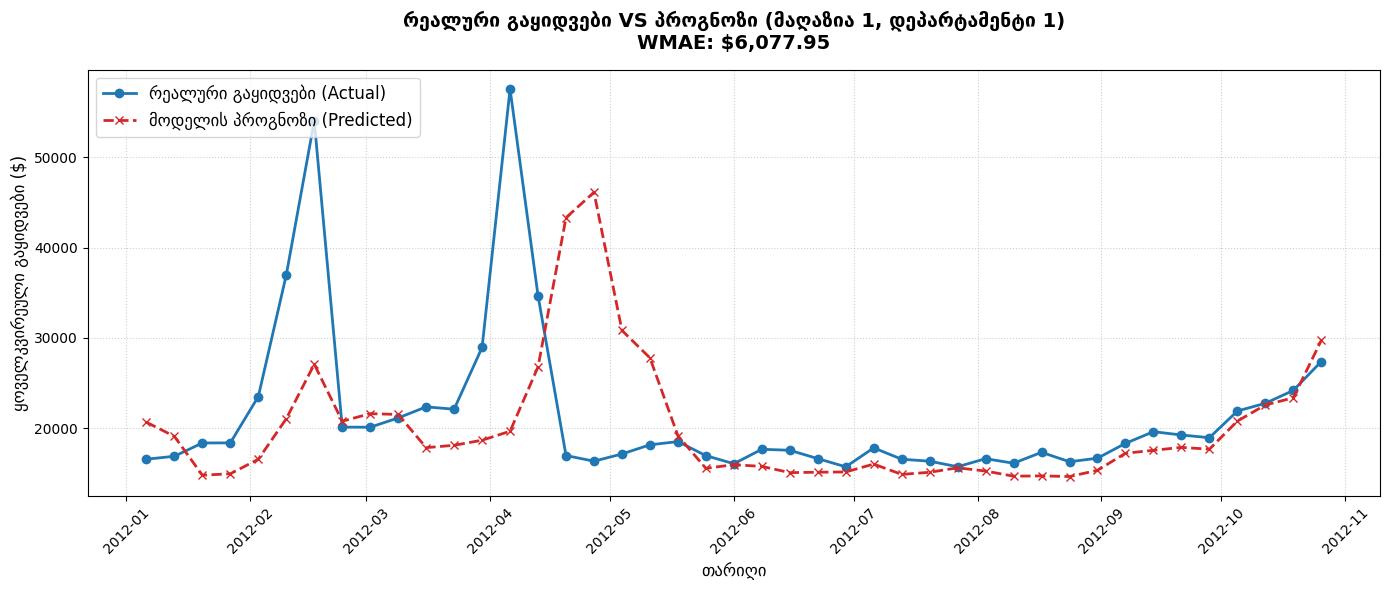

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# 1. შევქმნათ DataFrame ვალიდაციის რეალური პასუხებით და პროგნოზებით
val_results = X_val_raw.copy()
val_results['Actual_Sales'] = y_val
val_results['Predicted_Sales'] = val_preds
val_results['Date'] = pd.to_datetime(val_results['Date'])

# 2. ამოვარჩიოთ კონკრეტული მაღაზია და დეპარტამენტი ანალიზისთვის
sample_store = 1
sample_dept = 1
subset = val_results[(val_results['Store'] == sample_store) & (val_results['Dept'] == sample_dept)].sort_values('Date')

# 3. გამოვთვალოთ ლოკალური WMAE ამ კონკრეტული მაღაზიისთვის (გავითვალისწინოთ დღესასწაულის წონები)
if not subset.empty:
    weights = subset['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values if 'IsHoliday' in subset.columns else None
    specific_wmae = mean_absolute_error(subset['Actual_Sales'], subset['Predicted_Sales'], sample_weight=weights)
    title_text = f'რეალური გაყიდვები VS პროგნოზი (მაღაზია {sample_store}, დეპარტამენტი {sample_dept})\nWMAE: ${specific_wmae:,.2f}'
else:
    title_text = f'მონაცემები მაღაზია {sample_store}-სთვის და დეპარტამენტ {sample_dept}-სთვის ვერ მოიძებნა'

# 4. გრაფიკის აგება
plt.figure(figsize=(14, 6))
if not subset.empty:
    plt.plot(subset['Date'], subset['Actual_Sales'], label='რეალური გაყიდვები (Actual)', color='#1f77b4', linewidth=2, marker='o')
    plt.plot(subset['Date'], subset['Predicted_Sales'], label='მოდელის პროგნოზი (Predicted)', color='#d62728', linestyle='--', linewidth=2, marker='x')

plt.title(title_text, fontsize=14, fontweight='bold', pad=15)
plt.xlabel('თარიღი', fontsize=12)
plt.ylabel('ყოველკვირეული გაყიდვები ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
import mlflow.sklearn
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from walmart_transformers import WalmartDataTransformer_updatedFeatureEngineering, TimeSeriesSplitter,WalmartLagTransformer


train_df_lags=train_df.copy()
train_df_lags['Lag_51'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(51)
train_df_lags['Lag_52'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52)
train_df_lags['Lag_53'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(53)
train_df_lags['Rolling_Mean_4_Yearly'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52).rolling(window=4).mean()

train_df_lags = train_df_lags.dropna(subset=['Lag_52', 'Rolling_Mean_4_Yearly'])

# 2. ამის შემდეგ აკეთებ Split-ს
splitter = TimeSeriesSplitter(split_date='2012-01-01', target_col='Weekly_Sales')
X_train_raw, y_train, X_val_raw, y_val = splitter.split(train_df_lags)

train_weights = X_train_raw['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values if 'IsHoliday' in X_train_raw.columns else None
val_weights = X_val_raw['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values if 'IsHoliday' in X_val_raw.columns else None


best_params = {
    'subsample': 0.9,
    'n_estimators': 400,
    'min_child_weight': 3,
    'max_depth': 8,
    'learning_rate': 0.05,
    'gamma': 0.2,
    'colsample_bytree': 0.8
}

adv_pipeline_with_lags = Pipeline([
    ('data_prep', WalmartDataTransformer_updatedFeatureEngineering(features_df, stores_df)),
    ('model', xgb.XGBRegressor(**best_params))
])


adv_pipeline_with_lags.fit(X_train_raw, y_train, model__sample_weight=train_weights)


with mlflow.start_run(run_name="XGBoost_with_Many_Lags"):

    train_preds = adv_pipeline_with_lags.predict(X_train_raw)
    val_preds = adv_pipeline_with_lags.predict(X_val_raw)

    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    val_r2 = r2_score(y_val, val_preds)

    train_wmae = mean_absolute_error(y_train, train_preds, sample_weight=train_weights)
    val_wmae = mean_absolute_error(y_val, val_preds, sample_weight=val_weights)


    mlflow.log_param("model_type", "XGBoost_With_Lags_Pipeline")
    mlflow.log_param("split_date", "2012-01-01")
    mlflow.log_param("n_estimators", best_params['n_estimators'])
    mlflow.log_param("max_depth", best_params['max_depth'])
    mlflow.log_param("learning_rate", best_params['learning_rate'])


    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_r2", val_r2)
    mlflow.log_metric("train_wmae", train_wmae)
    mlflow.log_metric("val_wmae", val_wmae)

    mlflow.sklearn.log_model(adv_pipeline_with_lags, "all_in_one_lag_pipeline", serialization_format="cloudpickle")

    print("-" * 30)
    print(f"Lag Pipeline Run Ended Successfully!")
    print(f"Train MAE: ${train_mae:,.2f} | Train WMAE: ${train_wmae:,.2f}")
    print(f"Validation MAE: ${val_mae:,.2f} | Validation WMAE: ${val_wmae:,.2f}")

2026/07/11 03:34:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 03:34:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/11 03:35:00 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


------------------------------
Lag Pipeline Run Ended Successfully!
Train MAE: $1,094.74 | Train WMAE: $1,048.23
Validation MAE: $1,930.57 | Validation WMAE: $1,958.03
🏃 View run XGBoost_with_Many_Lags at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/4d62124ea1dc42e0876af71589e354d0
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0


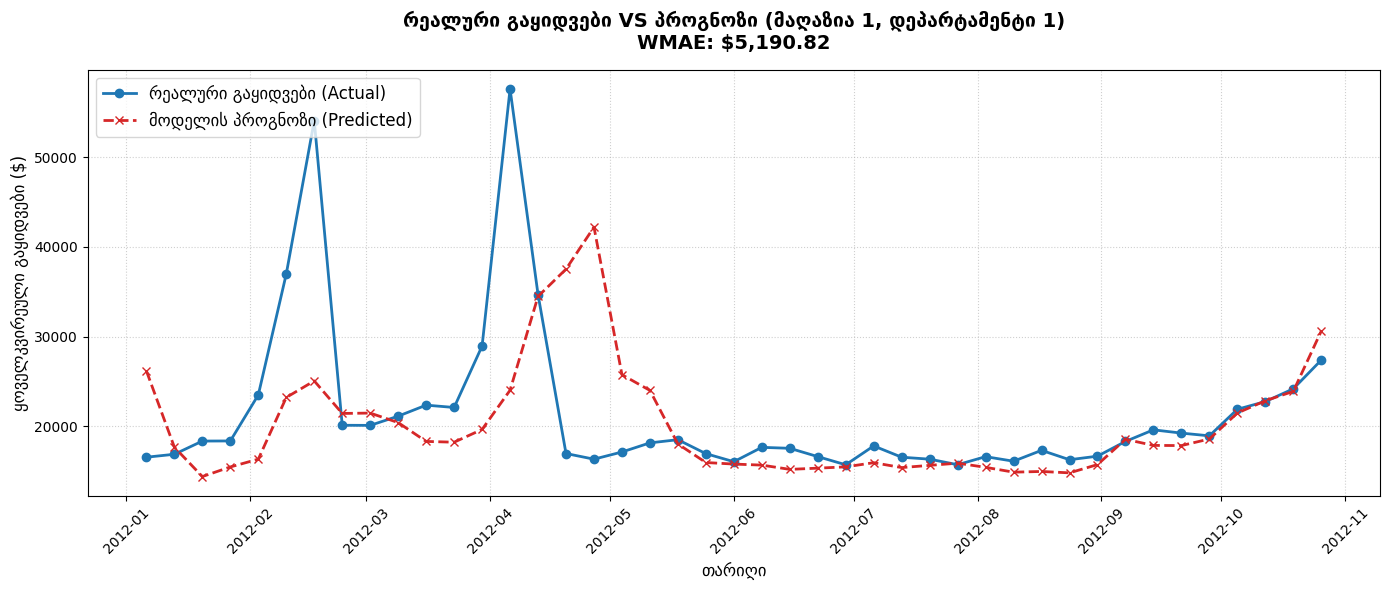

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# 1. შევქმნათ DataFrame ვალიდაციის რეალური პასუხებით და პროგნოზებით
val_results = X_val_raw.copy()
val_results['Actual_Sales'] = y_val
val_results['Predicted_Sales'] = val_preds
val_results['Date'] = pd.to_datetime(val_results['Date'])

# 2. ამოვარჩიოთ კონკრეტული მაღაზია და დეპარტამენტი ანალიზისთვის
sample_store = 1
sample_dept = 1
subset = val_results[(val_results['Store'] == sample_store) & (val_results['Dept'] == sample_dept)].sort_values('Date')

# 3. გამოვთვალოთ ლოკალური WMAE ამ კონკრეტული მაღაზიისთვის (გავითვალისწინოთ დღესასწაულის წონები)
if not subset.empty:
    weights = subset['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values if 'IsHoliday' in subset.columns else None
    specific_wmae = mean_absolute_error(subset['Actual_Sales'], subset['Predicted_Sales'], sample_weight=weights)
    title_text = f'რეალური გაყიდვები VS პროგნოზი (მაღაზია {sample_store}, დეპარტამენტი {sample_dept})\nWMAE: ${specific_wmae:,.2f}'
else:
    title_text = f'მონაცემები მაღაზია {sample_store}-სთვის და დეპარტამენტ {sample_dept}-სთვის ვერ მოიძებნა'

# 4. გრაფიკის აგება
plt.figure(figsize=(14, 6))
if not subset.empty:
    plt.plot(subset['Date'], subset['Actual_Sales'], label='რეალური გაყიდვები (Actual)', color='#1f77b4', linewidth=2, marker='o')
    plt.plot(subset['Date'], subset['Predicted_Sales'], label='მოდელის პროგნოზი (Predicted)', color='#d62728', linestyle='--', linewidth=2, marker='x')

plt.title(title_text, fontsize=14, fontweight='bold', pad=15)
plt.xlabel('თარიღი', fontsize=12)
plt.ylabel('ყოველკვირეული გაყიდვები ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



---

---



---



---





---



---



---



In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
import mlflow.sklearn
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from walmart_transformers import WalmartDataTransformer_updatedFeatureEngineering, TimeSeriesSplitter,WalmartLagTransformer


train_df_lags=train_df.copy()
train_df_lags['Lag_51'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(51)
train_df_lags['Lag_52'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52)
train_df_lags['Lag_53'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(53)
train_df_lags['Rolling_Mean_4_Yearly'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52).rolling(window=4).mean()

train_df_lags = train_df_lags.dropna(subset=['Lag_52', 'Rolling_Mean_4_Yearly'])

train_df_lags['Max_Sales_Yearly_Window'] = (
    train_df.groupby(['Store', 'Dept'])['Weekly_Sales']
    .shift(51) # ვიწყებთ შარშანდელიდან
    .rolling(window=3, center=True) # ვუყურებთ 3 კვირიან ფანჯარას (შარშანდელი კვირა, +1 კვირა, -1 კვირა)
    .max()
)

# 2. ამის შემდეგ აკეთებ Split-ს
splitter = TimeSeriesSplitter(split_date='2012-01-01', target_col='Weekly_Sales')
X_train_raw, y_train, X_val_raw, y_val = splitter.split(train_df_lags)

train_weights = X_train_raw['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values if 'IsHoliday' in X_train_raw.columns else None
val_weights = X_val_raw['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values if 'IsHoliday' in X_val_raw.columns else None


best_params = {
    'subsample': 0.9,
    'n_estimators': 400,
    'min_child_weight': 3,
    'max_depth': 8,
    'learning_rate': 0.05,
    'gamma': 0.2,
    'colsample_bytree': 0.8
}

adv_pipeline_with_lags = Pipeline([
    ('data_prep', WalmartDataTransformer_updatedFeatureEngineering(features_df, stores_df)),
    ('model', xgb.XGBRegressor(**best_params))
])


adv_pipeline_with_lags.fit(X_train_raw, y_train, model__sample_weight=train_weights)


with mlflow.start_run(run_name="XGBoost_with_Many_Lags"):

    train_preds = adv_pipeline_with_lags.predict(X_train_raw)
    val_preds = adv_pipeline_with_lags.predict(X_val_raw)

    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    val_r2 = r2_score(y_val, val_preds)

    train_wmae = mean_absolute_error(y_train, train_preds, sample_weight=train_weights)
    val_wmae = mean_absolute_error(y_val, val_preds, sample_weight=val_weights)


    mlflow.log_param("model_type", "XGBoost_With_Lags_Pipeline")
    mlflow.log_param("split_date", "2012-01-01")
    mlflow.log_param("n_estimators", best_params['n_estimators'])
    mlflow.log_param("max_depth", best_params['max_depth'])
    mlflow.log_param("learning_rate", best_params['learning_rate'])


    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_r2", val_r2)
    mlflow.log_metric("train_wmae", train_wmae)
    mlflow.log_metric("val_wmae", val_wmae)

    mlflow.sklearn.log_model(adv_pipeline_with_lags, "all_in_one_lag_pipeline", serialization_format="cloudpickle")

    print("-" * 30)
    print(f"Lag Pipeline Run Ended Successfully!")
    print(f"Train MAE: ${train_mae:,.2f} | Train WMAE: ${train_wmae:,.2f}")
    print(f"Validation MAE: ${val_mae:,.2f} | Validation WMAE: ${val_wmae:,.2f}")

2026/07/11 03:39:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 03:39:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/11 03:39:49 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


------------------------------
Lag Pipeline Run Ended Successfully!
Train MAE: $1,083.84 | Train WMAE: $1,038.94
Validation MAE: $2,060.37 | Validation WMAE: $2,069.33
🏃 View run XGBoost_with_Many_Lags at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/1d7d26c83f5d44a686555d2274aee041
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0


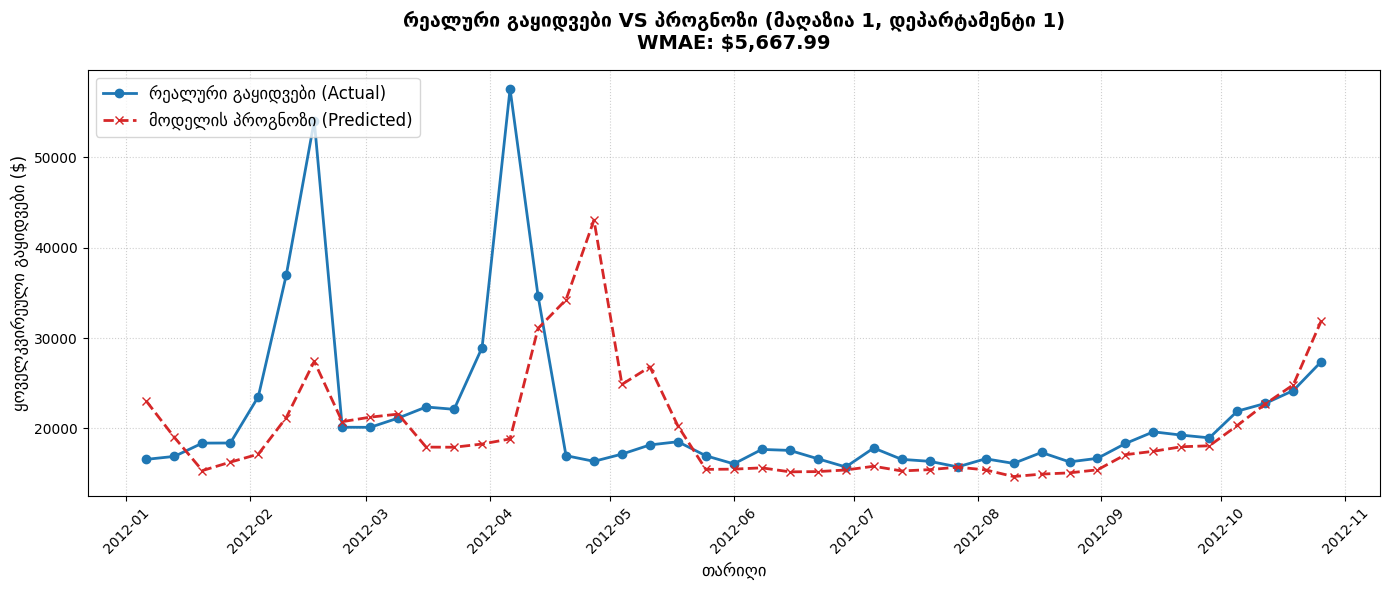

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# 1. შევქმნათ DataFrame ვალიდაციის რეალური პასუხებით და პროგნოზებით
val_results = X_val_raw.copy()
val_results['Actual_Sales'] = y_val
val_results['Predicted_Sales'] = val_preds
val_results['Date'] = pd.to_datetime(val_results['Date'])

# 2. ამოვარჩიოთ კონკრეტული მაღაზია და დეპარტამენტი ანალიზისთვის
sample_store = 1
sample_dept = 1
subset = val_results[(val_results['Store'] == sample_store) & (val_results['Dept'] == sample_dept)].sort_values('Date')

# 3. გამოვთვალოთ ლოკალური WMAE ამ კონკრეტული მაღაზიისთვის (გავითვალისწინოთ დღესასწაულის წონები)
if not subset.empty:
    weights = subset['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values if 'IsHoliday' in subset.columns else None
    specific_wmae = mean_absolute_error(subset['Actual_Sales'], subset['Predicted_Sales'], sample_weight=weights)
    title_text = f'რეალური გაყიდვები VS პროგნოზი (მაღაზია {sample_store}, დეპარტამენტი {sample_dept})\nWMAE: ${specific_wmae:,.2f}'
else:
    title_text = f'მონაცემები მაღაზია {sample_store}-სთვის და დეპარტამენტ {sample_dept}-სთვის ვერ მოიძებნა'

# 4. გრაფიკის აგება
plt.figure(figsize=(14, 6))
if not subset.empty:
    plt.plot(subset['Date'], subset['Actual_Sales'], label='რეალური გაყიდვები (Actual)', color='#1f77b4', linewidth=2, marker='o')
    plt.plot(subset['Date'], subset['Predicted_Sales'], label='მოდელის პროგნოზი (Predicted)', color='#d62728', linestyle='--', linewidth=2, marker='x')

plt.title(title_text, fontsize=14, fontweight='bold', pad=15)
plt.xlabel('თარიღი', fontsize=12)
plt.ylabel('ყოველკვირეული გაყიდვები ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
import mlflow.sklearn
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from walmart_transformers import WalmartDataTransformer_updatedFeatureEngineering, TimeSeriesSplitter,WalmartLagTransformer


train_df_lags=train_df.copy()
train_df_lags['Lag_51'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(51)
train_df_lags['Lag_52'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52)
train_df_lags['Lag_53'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(53)
train_df_lags['Rolling_Mean_4_Yearly'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52).rolling(window=4).mean()

train_df_lags = train_df_lags.dropna(subset=['Lag_52', 'Rolling_Mean_4_Yearly'])

train_df_lags['Max_Sales_Yearly_Window'] = (
    train_df.groupby(['Store', 'Dept'])['Weekly_Sales']
    .shift(51) # ვიწყებთ შარშანდელიდან
    .rolling(window=3, center=True) # ვუყურებთ 3 კვირიან ფანჯარას (შარშანდელი კვირა, +1 კვირა, -1 კვირა)
    .max()
)

# 2. ამის შემდეგ აკეთებ Split-ს
splitter = TimeSeriesSplitter(split_date='2012-01-01', target_col='Weekly_Sales')
X_train_raw, y_train, X_val_raw, y_val = splitter.split(train_df_lags)

train_weights = X_train_raw['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values if 'IsHoliday' in X_train_raw.columns else None
val_weights = X_val_raw['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values if 'IsHoliday' in X_val_raw.columns else None

best_params = {
    'n_estimators': 600,         # გავზარდეთ (ნელი სწავლისთვის)
    'max_depth': 5,              # 8-დან 5-ზე დავიყვანეთ (რათა არ დაიმახსოვროს ხმაური)
    'learning_rate': 0.02,       # დავწიეთ (უფრო ფრთხილად სწავლისთვის)
    'subsample': 0.7,            # დავწიეთ (რანდომიზაციის გასაზრდელად)
    'colsample_bytree': 0.7,     # დავწიეთ (ფიჩერების შერჩევის შესაზღუდად)
    'min_child_weight': 7,       # გავზარდეთ (რომ მცირე/ხმაურიან დაყოფებს არ ენდოს)
    'gamma': 0.3,                # გავზარდეთ (Pruning-ისთვის)
    'n_jobs': -1
}

adv_pipeline_with_lags_params = Pipeline([
    ('data_prep', WalmartDataTransformer_updatedFeatureEngineering(features_df, stores_df)),
    ('model', xgb.XGBRegressor(**best_params))
])


adv_pipeline_with_lags.fit(X_train_raw, y_train, model__sample_weight=train_weights)


with mlflow.start_run(run_name="XGBoost_with_Many_Lags_parameters"):

    train_preds = adv_pipeline_with_lags.predict(X_train_raw)
    val_preds = adv_pipeline_with_lags.predict(X_val_raw)

    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    val_r2 = r2_score(y_val, val_preds)

    train_wmae = mean_absolute_error(y_train, train_preds, sample_weight=train_weights)
    val_wmae = mean_absolute_error(y_val, val_preds, sample_weight=val_weights)


    mlflow.log_param("model_type", "XGBoost_With_Lags_Pipeline")
    mlflow.log_param("split_date", "2012-01-01")
    mlflow.log_param("n_estimators", best_params['n_estimators'])
    mlflow.log_param("max_depth", best_params['max_depth'])
    mlflow.log_param("learning_rate", best_params['learning_rate'])


    mlflow.log_metric("train_mae", train_mae)
    mlflow.log_metric("val_mae", val_mae)
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.log_metric("val_r2", val_r2)
    mlflow.log_metric("train_wmae", train_wmae)
    mlflow.log_metric("val_wmae", val_wmae)

    mlflow.sklearn.log_model(adv_pipeline_with_lags, "all_in_one_lag_pipeline", serialization_format="cloudpickle")

    print("-" * 30)
    print(f"Lag Pipeline Run Ended Successfully!")
    print(f"Train MAE: ${train_mae:,.2f} | Train WMAE: ${train_wmae:,.2f}")
    print(f"Validation MAE: ${val_mae:,.2f} | Validation WMAE: ${val_wmae:,.2f}")

2026/07/11 03:43:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 03:43:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/11 03:43:35 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


------------------------------
Lag Pipeline Run Ended Successfully!
Train MAE: $1,625.87 | Train WMAE: $1,645.25
Validation MAE: $1,906.70 | Validation WMAE: $1,927.71
🏃 View run XGBoost_with_Many_Lags_parameters at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/2b6ddc25915d430a897aae72fe86e2bc
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0


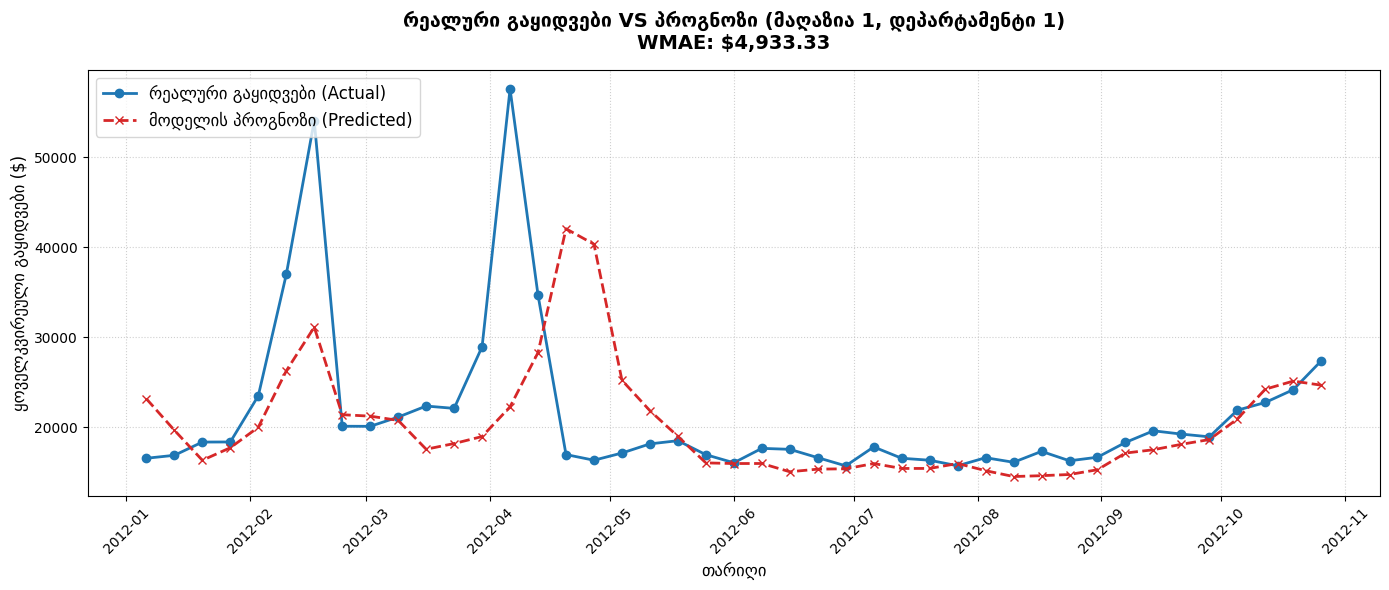

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# 1. შევქმნათ DataFrame ვალიდაციის რეალური პასუხებით და პროგნოზებით
val_results = X_val_raw.copy()
val_results['Actual_Sales'] = y_val
val_results['Predicted_Sales'] = val_preds
val_results['Date'] = pd.to_datetime(val_results['Date'])

# 2. ამოვარჩიოთ კონკრეტული მაღაზია და დეპარტამენტი ანალიზისთვის
sample_store = 1
sample_dept = 1
subset = val_results[(val_results['Store'] == sample_store) & (val_results['Dept'] == sample_dept)].sort_values('Date')

# 3. გამოვთვალოთ ლოკალური WMAE ამ კონკრეტული მაღაზიისთვის (გავითვალისწინოთ დღესასწაულის წონები)
if not subset.empty:
    weights = subset['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values if 'IsHoliday' in subset.columns else None
    specific_wmae = mean_absolute_error(subset['Actual_Sales'], subset['Predicted_Sales'], sample_weight=weights)
    title_text = f'რეალური გაყიდვები VS პროგნოზი (მაღაზია {sample_store}, დეპარტამენტი {sample_dept})\nWMAE: ${specific_wmae:,.2f}'
else:
    title_text = f'მონაცემები მაღაზია {sample_store}-სთვის და დეპარტამენტ {sample_dept}-სთვის ვერ მოიძებნა'

# 4. გრაფიკის აგება
plt.figure(figsize=(14, 6))
if not subset.empty:
    plt.plot(subset['Date'], subset['Actual_Sales'], label='რეალური გაყიდვები (Actual)', color='#1f77b4', linewidth=2, marker='o')
    plt.plot(subset['Date'], subset['Predicted_Sales'], label='მოდელის პროგნოზი (Predicted)', color='#d62728', linestyle='--', linewidth=2, marker='x')

plt.title(title_text, fontsize=14, fontweight='bold', pad=15)
plt.xlabel('თარიღი', fontsize=12)
plt.ylabel('ყოველკვირეული გაყიდვები ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from walmart_transformers import WalmartDataTransformer_updatedFeatureEngineering, TimeSeriesSplitter

# ჯერ ვაწყობთ ლაგებიან სრულ train_df_lags-ს (იგივე, რაც აქამდე)
train_df_lags = train_df.copy()
train_df_lags['Lag_51'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(51)
train_df_lags['Lag_52'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52)
train_df_lags['Lag_53'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(53)
train_df_lags['Rolling_Mean_4_Yearly'] = train_df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52).rolling(window=4).mean()
train_df_lags['Max_Sales_Yearly_Window'] = (
    train_df.groupby(['Store', 'Dept'])['Weekly_Sales']
    .shift(51).rolling(window=3, center=True).max()
)
train_df_lags = train_df_lags.dropna(subset=['Lag_52', 'Rolling_Mean_4_Yearly'])
train_df_lags['Date'] = pd.to_datetime(train_df_lags['Date'])

print("მონაცემების დიაპაზონი:", train_df_lags['Date'].min(), "-", train_df_lags['Date'].max())

best_params = {
    'n_estimators': 600,
    'max_depth': 5,
    'learning_rate': 0.02,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'min_child_weight': 7,
    'gamma': 0.3,
    'n_jobs': -1
}

def compute_wmae(y_true, y_pred, is_holiday, holiday_weight=5):
    weights = np.where(is_holiday, holiday_weight, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

# --- Expanding-window split-ები ---
# ყოველი split ვამზადებთ ~3-თვიან validation window-ს
split_dates = [
    ('2011-10-01', '2012-01-01'),
    ('2012-01-01', '2012-04-01'),
    ('2012-04-01', '2012-07-01'),
    ('2012-07-01', '2012-10-01'),
]

cv_results = []

for train_end, val_end in split_dates:
    train_mask = train_df_lags['Date'] < train_end
    val_mask = (train_df_lags['Date'] >= train_end) & (train_df_lags['Date'] < val_end)

    X_tr = train_df_lags[train_mask].drop(columns=['Weekly_Sales'])
    y_tr = train_df_lags[train_mask]['Weekly_Sales']
    X_va = train_df_lags[val_mask].drop(columns=['Weekly_Sales'])
    y_va = train_df_lags[val_mask]['Weekly_Sales']

    if len(X_va) == 0 or len(X_tr) == 0:
        print(f"⚠️ გამოტოვებულია split {train_end}-{val_end}: ცარიელი ნაწილი")
        continue

    tr_weights = X_tr['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values

    fold_pipeline = Pipeline([
        ('data_prep', WalmartDataTransformer_updatedFeatureEngineering(features_df, stores_df)),
        ('model', xgb.XGBRegressor(**best_params))
    ])

    fold_pipeline.fit(X_tr, y_tr, model__sample_weight=tr_weights)

    val_preds = fold_pipeline.predict(X_va)
    val_mae = mean_absolute_error(y_va, val_preds)
    val_wmae = compute_wmae(y_va.values, val_preds, X_va['IsHoliday'].values)

    cv_results.append({
        'train_end': train_end,
        'val_end': val_end,
        'n_train': len(X_tr),
        'n_val': len(X_va),
        'val_mae': val_mae,
        'val_wmae': val_wmae
    })

    print(f"Fold [{train_end} → {val_end}]: MAE=${val_mae:,.2f} | WMAE=${val_wmae:,.2f} | n_val={len(X_va)}")

cv_df = pd.DataFrame(cv_results)
print("\n=== CV შედეგები ===")
print(cv_df)
print(f"\nსაშუალო WMAE: {cv_df['val_wmae'].mean():.2f} ± {cv_df['val_wmae'].std():.2f}")
print(f"საშუალო MAE:  {cv_df['val_mae'].mean():.2f} ± {cv_df['val_mae'].std():.2f}")

მონაცემების დიაპაზონი: 2011-02-25 00:00:00 - 2012-10-26 00:00:00
Fold [2011-10-01 → 2012-01-01]: MAE=$2,658.91 | WMAE=$3,246.13 | n_val=37462
Fold [2012-01-01 → 2012-04-01]: MAE=$2,063.62 | WMAE=$2,121.15 | n_val=37576
Fold [2012-04-01 → 2012-07-01]: MAE=$1,833.56 | WMAE=$1,833.56 | n_val=37632
Fold [2012-07-01 → 2012-10-01]: MAE=$1,590.54 | WMAE=$1,610.55 | n_val=37683

=== CV შედეგები ===
    train_end     val_end  n_train  n_val      val_mae     val_wmae
0  2011-10-01  2012-01-01    90087  37462  2658.905643  3246.128460
1  2012-01-01  2012-04-01   127549  37576  2063.620502  2121.146940
2  2012-04-01  2012-07-01   165125  37632  1833.562003  1833.562003
3  2012-07-01  2012-10-01   202757  37683  1590.543025  1610.546400

საშუალო WMAE: 2202.85 ± 726.25
საშუალო MAE:  2036.66 ± 457.60


In [12]:
import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

def compute_wmae(y_true, y_pred, is_holiday, holiday_weight=5):
    weights = np.where(is_holiday, holiday_weight, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

split_dates = [
    ('2011-10-01', '2012-01-01'),
    ('2012-01-01', '2012-04-01'),
    ('2012-04-01', '2012-07-01'),
    ('2012-07-01', '2012-10-01'),
]

def run_cv_with_mlflow(use_lags, best_params, split_dates, parent_run_name):
    results = []
    with mlflow.start_run(run_name=parent_run_name) as parent_run:
        mlflow.log_param("use_lags", use_lags)
        for param_name, param_val in best_params.items():
            mlflow.log_param(param_name, param_val)

        for train_end, val_end in split_dates:
            if use_lags:
                base_df = train_df_lags.copy()
            else:
                base_df = train_df.copy()
                base_df['Date'] = pd.to_datetime(base_df['Date'])

            train_mask = base_df['Date'] < train_end
            val_mask = (base_df['Date'] >= train_end) & (base_df['Date'] < val_end)

            X_tr = base_df[train_mask].drop(columns=['Weekly_Sales'])
            y_tr = base_df[train_mask]['Weekly_Sales']
            X_va = base_df[val_mask].drop(columns=['Weekly_Sales'])
            y_va = base_df[val_mask]['Weekly_Sales']

            if len(X_va) == 0 or len(X_tr) == 0:
                continue

            tr_w = X_tr['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values

            with mlflow.start_run(run_name=f"fold_{train_end}_to_{val_end}", nested=True):
                pipe = Pipeline([
                    ('data_prep', WalmartDataTransformer_updatedFeatureEngineering(features_df, stores_df)),
                    ('model', xgb.XGBRegressor(random_state=42, n_jobs=-1, **best_params))
                ])
                pipe.fit(X_tr, y_tr, model__sample_weight=tr_w)

                val_preds = pipe.predict(X_va)
                mae = mean_absolute_error(y_va, val_preds)
                wmae = compute_wmae(y_va.values, val_preds, X_va['IsHoliday'].values)

                mlflow.log_param("train_end", train_end)
                mlflow.log_param("val_end", val_end)
                mlflow.log_param("n_train", len(X_tr))
                mlflow.log_param("n_val", len(X_va))
                mlflow.log_metric("val_mae", mae)
                mlflow.log_metric("val_wmae", wmae)

                results.append({'train_end': train_end, 'val_end': val_end, 'mae': mae, 'wmae': wmae, 'n_val': len(X_va)})
                print(f"[{'LAGS' if use_lags else 'NO-LAGS'}] {train_end}→{val_end}: MAE=${mae:,.2f} | WMAE=${wmae:,.2f}")

        results_df = pd.DataFrame(results)
        mean_wmae = results_df['wmae'].mean()
        std_wmae = results_df['wmae'].std()
        mean_mae = results_df['mae'].mean()

        # საბოლოო შეჯამებული მეტრიკები parent run-ზე
        mlflow.log_metric("cv_mean_wmae", mean_wmae)
        mlflow.log_metric("cv_std_wmae", std_wmae)
        mlflow.log_metric("cv_mean_mae", mean_mae)

        print(f"\n=== {parent_run_name} შედეგი ===")
        print(f"საშუალო WMAE: {mean_wmae:.2f} ± {std_wmae:.2f}")
        print(f"საშუალო MAE:  {mean_mae:.2f}")

    return results_df

best_params_new = {
    'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 3,
    'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.8
}

best_params_old = {
    'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.02,
    'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 7, 'gamma': 0.3
}

print("### CV: ლაგებით, ძველი params ###")
cv_lags_old = run_cv_with_mlflow(True, best_params_old, split_dates, "CV_WithLags_OldParams")

print("\n### CV: ლაგებით, ახალი params ###")
cv_lags_new = run_cv_with_mlflow(True, best_params_new, split_dates, "CV_WithLags_NewParams")

print("\n### CV: ლაგების გარეშე, ახალი params ###")
cv_nolags_new = run_cv_with_mlflow(False, best_params_new, split_dates, "CV_NoLags_NewParams")

print("\n\n=== საბოლოო შედარება ===")
print(f"ლაგებით (ძველი params):    {cv_lags_old['wmae'].mean():.2f} ± {cv_lags_old['wmae'].std():.2f}")
print(f"ლაგებით (ახალი params):    {cv_lags_new['wmae'].mean():.2f} ± {cv_lags_new['wmae'].std():.2f}")
print(f"ლაგების გარეშე (ახალი):    {cv_nolags_new['wmae'].mean():.2f} ± {cv_nolags_new['wmae'].std():.2f}")

### CV: ლაგებით, ძველი params ###
[LAGS] 2011-10-01→2012-01-01: MAE=$2,661.13 | WMAE=$3,267.95
🏃 View run fold_2011-10-01_to_2012-01-01 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/811403e319ea4777ab9cc3896c34afd2
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0
[LAGS] 2012-01-01→2012-04-01: MAE=$2,052.27 | WMAE=$2,095.98
🏃 View run fold_2012-01-01_to_2012-04-01 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/8d28bcd184cc48da8d06c86a4f4f0b3c
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0
[LAGS] 2012-04-01→2012-07-01: MAE=$1,835.76 | WMAE=$1,835.76
🏃 View run fold_2012-04-01_to_2012-07-01 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/95a8fdc8af75464982e437dcae28681d
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales

In [13]:
import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

# ==========================================
# 1. Holiday-ტიპის ფიჩერების დამატება
# ==========================================
SUPER_BOWL = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
LABOR_DAY = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
THANKSGIVING = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
CHRISTMAS = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

def add_holiday_type_features(df):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df['Is_SuperBowl'] = df['Date'].isin(SUPER_BOWL).astype(int)
    df['Is_LaborDay'] = df['Date'].isin(LABOR_DAY).astype(int)
    df['Is_Thanksgiving'] = df['Date'].isin(THANKSGIVING).astype(int)
    df['Is_Christmas'] = df['Date'].isin(CHRISTMAS).astype(int)

    # უახლოესი Christmas-მდე დარჩენილი კვირები (შეიძლება უარყოფითიც იყოს, თუ Christmas გავიდა)
    all_christmas_sorted = CHRISTMAS.sort_values()
    def weeks_to_nearest_christmas(d):
        future = all_christmas_sorted[all_christmas_sorted >= d]
        if len(future) == 0:
            return np.nan
        return (future.min() - d).days / 7

    df['Weeks_To_Christmas'] = df['Date'].apply(weeks_to_nearest_christmas)
    return df

train_df_lags_holiday = add_holiday_type_features(train_df_lags)

# საკონტროლო შემოწმება
print(train_df_lags_holiday[['Date','Is_Thanksgiving','Is_Christmas','Is_SuperBowl','Is_LaborDay']].query(
    'Is_Thanksgiving==1 or Is_Christmas==1 or Is_SuperBowl==1 or Is_LaborDay==1'
).drop_duplicates(subset='Date').sort_values('Date'))

print(f"\nThanksgiving: {train_df_lags_holiday['Is_Thanksgiving'].sum()} სტრიქონი")
print(f"Christmas: {train_df_lags_holiday['Is_Christmas'].sum()} სტრიქონი")
print(f"SuperBowl: {train_df_lags_holiday['Is_SuperBowl'].sum()} სტრიქონი")
print(f"LaborDay: {train_df_lags_holiday['Is_LaborDay'].sum()} სტრიქონი")

          Date  Is_Thanksgiving  Is_Christmas  Is_SuperBowl  Is_LaborDay
83  2011-09-09                0             0             0            1
94  2011-11-25                1             0             0            0
99  2011-12-30                0             1             0            0
105 2012-02-10                0             0             1            0
135 2012-09-07                0             0             0            1

Thanksgiving: 2893 სტრიქონი
Christmas: 2897 სტრიქონი
SuperBowl: 2892 სტრიქონი
LaborDay: 5760 სტრიქონი


In [15]:
def compute_wmae(y_true, y_pred, is_holiday, holiday_weight=5):
    weights = np.where(is_holiday, holiday_weight, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

best_params_old = {
    'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.02,
    'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 7, 'gamma': 0.3
}

split_dates = [
    ('2011-10-01', '2012-01-01'),
    ('2012-01-01', '2012-04-01'),
    ('2012-04-01', '2012-07-01'),
    ('2012-07-01', '2012-10-01'),
]

def run_cv_with_mlflow_v2(base_df, best_params, split_dates, parent_run_name):
    results = []
    with mlflow.start_run(run_name=parent_run_name):
        mlflow.log_param("features", "holiday_type" if "Is_Thanksgiving" in base_df.columns else "base")
        for param_name, param_val in best_params.items():
            mlflow.log_param(param_name, param_val)

        for train_end, val_end in split_dates:
            train_mask = base_df['Date'] < train_end
            val_mask = (base_df['Date'] >= train_end) & (base_df['Date'] < val_end)

            X_tr = base_df[train_mask].drop(columns=['Weekly_Sales'])
            y_tr = base_df[train_mask]['Weekly_Sales']
            X_va = base_df[val_mask].drop(columns=['Weekly_Sales'])
            y_va = base_df[val_mask]['Weekly_Sales']

            if len(X_va) == 0 or len(X_tr) == 0:
                continue

            tr_w = X_tr['IsHoliday'].apply(lambda x: 5 if x == 1 else 1).values

            with mlflow.start_run(run_name=f"fold_{train_end}_to_{val_end}", nested=True):
                pipe = Pipeline([
                    ('data_prep', WalmartDataTransformer_updatedFeatureEngineering(features_df, stores_df)),
                    ('model', xgb.XGBRegressor(random_state=42, n_jobs=-1, **best_params))
                ])
                pipe.fit(X_tr, y_tr, model__sample_weight=tr_w)

                val_preds = pipe.predict(X_va)
                mae = mean_absolute_error(y_va, val_preds)
                wmae = compute_wmae(y_va.values, val_preds, X_va['IsHoliday'].values)

                mlflow.log_param("train_end", train_end)
                mlflow.log_param("val_end", val_end)
                mlflow.log_metric("val_mae", mae)
                mlflow.log_metric("val_wmae", wmae)

                results.append({'train_end': train_end, 'val_end': val_end, 'mae': mae, 'wmae': wmae})
                print(f"{train_end}→{val_end}: MAE=${mae:,.2f} | WMAE=${wmae:,.2f}")

        results_df = pd.DataFrame(results)
        mean_wmae = results_df['wmae'].mean()
        std_wmae = results_df['wmae'].std()

        mlflow.log_metric("cv_mean_wmae", mean_wmae)
        mlflow.log_metric("cv_std_wmae", std_wmae)

        print(f"\n=== {parent_run_name} ===")
        print(f"საშუალო WMAE: {mean_wmae:.2f} ± {std_wmae:.2f}")

    return results_df

print("### CV: ლაგები + Holiday-ტიპის ფიჩერები, ძველი params ###")
cv_holiday_features = run_cv_with_mlflow_v2(train_df_lags_holiday, best_params_old, split_dates, "CV_LagsPlusHolidayFeatures")

print(f"\n\n=== საბოლოო შედარება ===")
print(f"ლაგებით (baseline, submission-ში):     2202.12 ± 737.90")
print(f"ლაგები + Holiday-ტიპის ფიჩერები:       {cv_holiday_features['wmae'].mean():.2f} ± {cv_holiday_features['wmae'].std():.2f}")

if cv_holiday_features['wmae'].mean() < 2202.12:
    print("\n✅ Holiday-ტიპის ფიჩერები აუმჯობესებს მოდელს — ეს უნდა წავიდეს submission-ისთვის")
else:
    print("\n❌ Holiday-ტიპის ფიჩერები არ აუმჯობესებს — ვრჩებით ორიგინალ (baseline) მოდელზე")

### CV: ლაგები + Holiday-ტიპის ფიჩერები, ძველი params ###
2011-10-01→2012-01-01: MAE=$2,667.02 | WMAE=$3,297.14
🏃 View run fold_2011-10-01_to_2012-01-01 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/c34a6ca278c64fa789b02b4893e4dc40
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0
2012-01-01→2012-04-01: MAE=$2,054.35 | WMAE=$2,124.00
🏃 View run fold_2012-01-01_to_2012-04-01 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/32a907c432a44ecf9cba0f9211e6015c
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0
2012-04-01→2012-07-01: MAE=$1,832.45 | WMAE=$1,832.45
🏃 View run fold_2012-04-01_to_2012-07-01 at: https://dagshub.com/mesata/Walmart---Store-Sales-Forecasting.mlflow/#/experiments/0/runs/6bc3e3d48dcd4c5a8cf6bf7a4aec561d
🧪 View experiment at: https://dagshub.com/mesata/Walmart---Store-Sa